## Module 12 Time-Series Forecasting
### Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [2]:
apmm12t01 = pd.read_csv("APMM12-timeseries01.csv")

In [3]:
apmm12t01.head()

,date,value
0,2020-01-01,0.159764
1,2020-01-02,0.564730
2,2020-01-03,1.911643
3,2020-01-04,0.679665
4,2020-01-05,-0.374629


<Figure size 1000x400 with 0 Axes>

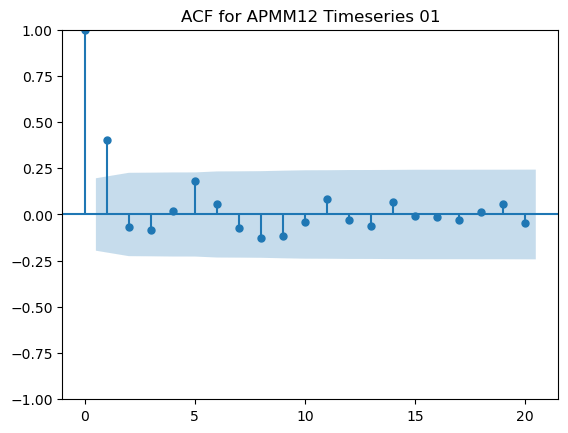

In [4]:
plt.figure(figsize=(10,4))
plot_acf(apmm12t01.value, lags=20)
plt.title("ACF for APMM12 Timeseries 01")
plt.show()

<Figure size 1000x400 with 0 Axes>

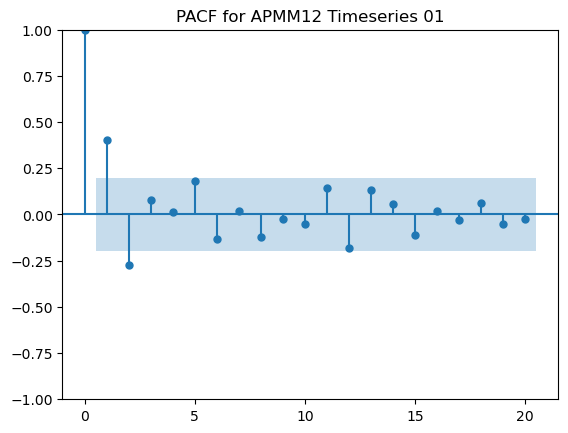

In [5]:
plt.figure(figsize=(10,4))
plot_pacf(apmm12t01.value, lags=20)
plt.title("PACF for APMM12 Timeseries 01")
plt.show()

In [6]:
t01adf = adfuller(apmm12t01.value)[1]

In [7]:
print(f"(ADF Value: {t01adf:.4f}")

(ADF Value: 0.0000


In [8]:
# Fitting a MA(1) for Time Series 01
model_ma01 = ARIMA(apmm12t01.value, order=(0,0,1))
res01 = model_ma01.fit()

In [9]:
print(res01.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -132.830
Date:                Mon, 04 Aug 2025   AIC                            271.660
Time:                        00:44:37   BIC                            279.476
Sample:                             0   HQIC                           274.823
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1908      0.149     -1.278      0.201      -0.483       0.102
ma.L1          0.6343      0.082      7.763      0.000       0.474       0.795
sigma2         0.8299      0.128      6.508      0.0

In [10]:
# Time Series 02
apmm12t02 = pd.read_csv("APMM12-timeseries02.csv")

<Figure size 1000x600 with 0 Axes>

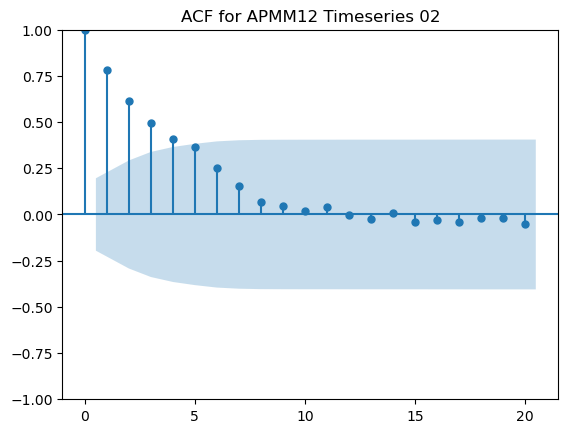

In [11]:
plt.figure(figsize=(10,6))
plot_acf(apmm12t02.value, lags=20)
plt.title("ACF for APMM12 Timeseries 02")
plt.show()

<Figure size 1000x600 with 0 Axes>

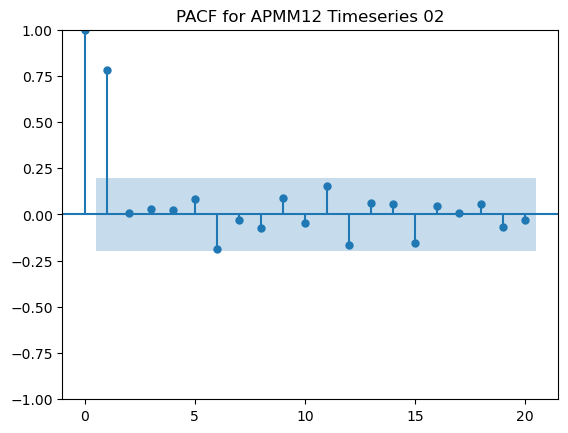

In [12]:
plt.figure(figsize=(10,6))
plot_pacf(apmm12t02.value, lags=20)
plt.title("PACF for APMM12 Timeseries 02")
plt.show()

In [13]:
t02adf = adfuller(apmm12t02.value)[1]
t02adf

0.00910570814399415

In [14]:
t02adf

0.00910570814399415

In [15]:
# Fitting an AR(1) Model
model_ar02 = ARIMA(apmm12t02.value, order=(1,0,0))
res_ar02 = model_ar02.fit()
print(res_ar02.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -132.206
Date:                Mon, 04 Aug 2025   AIC                            270.413
Time:                        00:44:37   BIC                            278.228
Sample:                             0   HQIC                           273.576
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4658      0.407     -1.146      0.252      -1.263       0.331
ar.L1          0.7787      0.058     13.516      0.000       0.666       0.892
sigma2         0.8162      0.125      6.522      0.0

In [16]:
# Time Series 04
apmm12t04 = pd.read_csv("APMM12-timeseries04.csv", index_col="date", parse_dates=True)
apmm12t04.index.freq = 'D'

In [17]:
apmm12t04.head()

,value
date,
2020-01-01,-0.408873
2020-01-02,-0.995491
2020-01-03,-2.774890
2020-01-04,-5.787595
2020-01-05,-7.870965


<Figure size 1000x600 with 0 Axes>

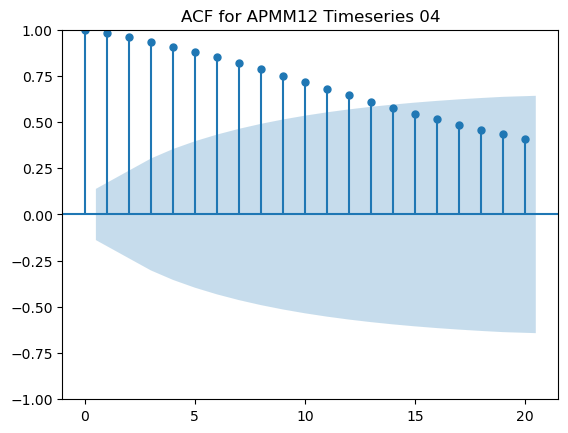

In [36]:
plt.figure(figsize=(10,6))
plot_acf(apmm12t04, lags=20)
plt.title("ACF for APMM12 Timeseries 04")
plt.show()

<Figure size 1000x600 with 0 Axes>

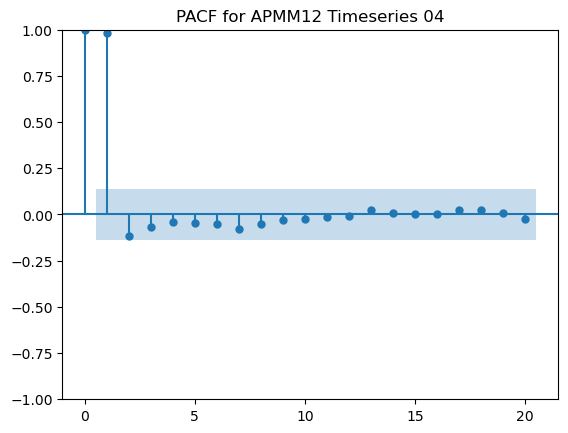

In [37]:
plt.figure(figsize=(10,6))
plot_pacf(apmm12t04, lags=20)
plt.title("PACF for APMM12 Timeseries 04")
plt.show()

In [38]:
t04adf = adfuller(apmm12t04)[1]

In [39]:
t04adf

0.43272462345167717

In [40]:
t04adf_diff = adfuller(apmm12t04.diff().dropna())[1]

In [41]:
t04adf_diff

0.004928055061026027

In [42]:
train_size = int(len(apmm12t04)*0.75)

In [43]:
train, test = apmm12t04.iloc[:train_size], apmm12t04.iloc[train_size:]

In [44]:
train.shape

(150, 1)

In [45]:
test.shape

(50, 1)

In [46]:
# ARIMA(1,1,1) Model
model_arima111 = ARIMA(train, order=(1,1,1))
res_arima111 = model_arima111.fit()

In [48]:
print(res_arima111.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  150
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -194.327
Date:                Mon, 04 Aug 2025   AIC                            394.654
Time:                        00:45:27   BIC                            403.666
Sample:                    01-01-2020   HQIC                           398.316
                         - 05-29-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8298      0.055     14.972      0.000       0.721       0.938
ma.L1          0.5442      0.069      7.909      0.000       0.409       0.679
sigma2         0.7830      0.087      9.008      0.0

In [49]:
forecast_arima111 = res_arima111.forecast(steps=len(test))
forecast_arima111 = pd.Series(forecast_arima111, index=test.index)

In [64]:
test_val = test.values
fore_val = forecast_arima111.values

In [65]:
test_val.shape

(50, 1)

In [66]:
fore_val.shape

(50,)

In [69]:
np.sqrt(np.mean((test_val - fore_val)**2))

13.014820205651231